In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model

# Load the data
df = pd.read_csv('HousingData.csv')
# Prepare the data
df = df.fillna(df.median())
print (df)


        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  \
0    0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296   
1    0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242   
2    0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242   
3    0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222   
4    0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...  ...   
501  0.06263   0.0  11.93   0.0  0.573  6.593  69.1  2.4786    1  273   
502  0.04527   0.0  11.93   0.0  0.573  6.120  76.7  2.2875    1  273   
503  0.06076   0.0  11.93   0.0  0.573  6.976  91.0  2.1675    1  273   
504  0.10959   0.0  11.93   0.0  0.573  6.794  89.3  2.3889    1  273   
505  0.04741   0.0  11.93   0.0  0.573  6.030  76.8  2.5050    1  273   

     PTRATIO       B  LSTAT  MEDV  
0       15.3  396.90   4.98  24.0  
1       17.8  396.90   9.14  21.6  
2       17.8  3

In [2]:
print(df.isna().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [ ]:
#Training the model
reg = linear_model.LinearRegression()
reg.fit(df[['CRIM','ZN','INDUS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT']], df['MEDV'])
print('Coefficients: \n', reg.coef_)
print('Intercept: \n', reg.intercept_)


Coefficients: 
 [-1.13987333e-01  4.06601102e-02 -1.58940285e-02 -1.65371252e+01
  4.15870581e+00 -6.45568662e-03 -1.48585053e+00  2.91096062e-01
 -1.21295912e-02 -9.74166692e-01  9.69568944e-03 -4.75872859e-01]
Intercept: 
 34.50651926060179


In [11]:
pred = reg.predict(df[['CRIM','ZN','INDUS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT']])
predicted = reg.predict(pd.DataFrame({"CRIM": [0.85], "ZN": [0], "INDUS": [7], "NOX": [0.53], "RM": [6.012], 
                                      "AGE": [50], "DIS": [4.5], "RAD": [3], "TAX": [300], "PTRATIO": [15.5], 
                                      "B": [391], "LSTAT": [7.32]}))
print(predicted)

[25.96917547]


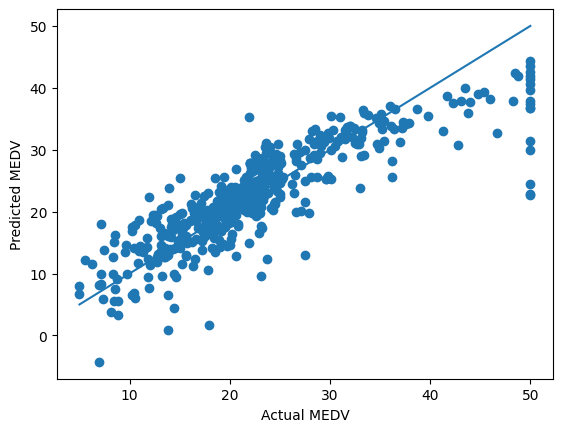

In [12]:
plt.scatter(df['MEDV'], pred)
plt.xlabel('Actual MEDV')
plt.ylabel('Predicted MEDV')
plt.plot([df['MEDV'].min(), df['MEDV'].max()],
         [df['MEDV'].min(), df['MEDV'].max()])
plt.show()